<a href="https://colab.research.google.com/github/Sandipsen877/honey_chain_project/blob/main/HONEY_CHAIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## HIVE MONITORING MODEL


#### *IMPORTING REQUIRED LIBRARIES*

In [ ]:
!pip install -q pandas numpy scikit-learn joblib matplotlib

#### *IMPORTING FILE DIRECTLY FROM GOOGLE DRIVE*

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os
import glob

matches = glob.glob(
    "/content/drive/MyDrive/**/SensorLog.csv",
    recursive=True
)

if len(matches) == 0:
    raise FileNotFoundError(
        "SensorLog.csv was not found anywhere inside Google Drive."
    )

print("Files found:")

for file in matches:
    print(file)

DATA_FILE = matches[0]

DRIVE_FOLDER = os.path.dirname(DATA_FILE)

print("\nUsing dataset:")
print(DATA_FILE)

print("\nHive project folder:")
print(DRIVE_FOLDER)

Files found:
/content/drive/MyDrive/HONEY_HEALTH_MONITOR/SensorLog.csv

Using dataset:
/content/drive/MyDrive/HONEY_HEALTH_MONITOR/SensorLog.csv

Hive project folder:
/content/drive/MyDrive/HONEY_HEALTH_MONITOR


### *COMPLETE ML MODEL AND HEALTH ENGINE:*

In [ ]:
# ============================================================
# HONEY CHAIN - BEE HIVE HEALTH INTELLIGENCE ENGINE
# ============================================================
import os
import json
import joblib
import warnings
import numpy as np
import pandas as pd

from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
warnings.filterwarnings("ignore")

# ============================================================
# CONFIGURATION
# ============================================================

MODEL_FOLDER = os.path.join(DRIVE_FOLDER, "models")
REPORT_FOLDER = os.path.join(DRIVE_FOLDER, "reports")
os.makedirs(MODEL_FOLDER, exist_ok=True)
os.makedirs(REPORT_FOLDER, exist_ok=True)

# Number of latest readings used for CURRENT health report
RECENT_WINDOW = 12

# ============================================================
# REQUIRED COLUMNS
# ============================================================

COMMON_COLUMNS = [

    "Timestamp",

    "CO2_eq (ppm)",
    "TVOC (ppb)",

    "TempOut (°C)",
    "HumOut (%)",

    "Pressure (hPa)",
    "Light (-)",

    "BeeIn (-)",
    "BeeOut (-)"
]


HIVE_COLUMNS = {

    1: {
        "temp": "TempIn_1 (°C)",
        "humidity": "HumIn_1 (%)"
    },

    2: {
        "temp": "TempIn_2 (°C)",
        "humidity": "HumIn_2 (%)"
    }

}


# ============================================================
# LOAD DATA
# ============================================================

def load_sensor_data(file_path):

    print("Loading:", file_path)

    # Your actual dataset uses semicolon
    df = pd.read_csv(file_path, sep=";")

    print("Rows:", len(df))
    print("Columns:", len(df.columns))

    return df


# ============================================================
# VALIDATE DATASET
# ============================================================

def validate_dataset(df):

    required = COMMON_COLUMNS.copy()

    for hive_id in HIVE_COLUMNS:

        required.append(
            HIVE_COLUMNS[hive_id]["temp"]
        )

        required.append(
            HIVE_COLUMNS[hive_id]["humidity"]
        )


    missing = [
        col for col in required
        if col not in df.columns
    ]


    if missing:

        raise ValueError(
            f"Missing required columns: {missing}"
        )


    print("Dataset validation successful.")


# ============================================================
# CLEAN DATA
# ============================================================

def clean_data(df):

    df = df.copy()


    # Convert timestamp
    df["Timestamp"] = pd.to_datetime(
        df["Timestamp"],
        format="%y.%m.%d %H:%M:%S",
        errors="coerce"
    )


    numeric_columns = [

        "CO2_eq (ppm)",
        "TVOC (ppb)",

        "TempIn_1 (°C)",
        "HumIn_1 (%)",

        "TempIn_2 (°C)",
        "HumIn_2 (%)",

        "TempOut (°C)",
        "HumOut (%)",

        "Pressure (hPa)",
        "Light (-)",

        "BeeIn (-)",
        "BeeOut (-)"
    ]


    for col in numeric_columns:

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )


    # Remove rows without timestamp
    df = df.dropna(
        subset=["Timestamp"]
    )


    # Sort chronologically
    df = df.sort_values(
        "Timestamp"
    ).reset_index(drop=True)


    return df


# ============================================================
# FEATURE ENGINEERING
# ============================================================

def create_features(df, hive_id):

    data = df.copy()

    temp_col = HIVE_COLUMNS[hive_id]["temp"]
    humidity_col = HIVE_COLUMNS[hive_id]["humidity"]


    # --------------------------------------------------------
    # Rename hive-specific variables
    # --------------------------------------------------------

    data["HiveTemp"] = data[temp_col]

    data["HiveHumidity"] = data[humidity_col]


    # --------------------------------------------------------
    # Bee activity
    # --------------------------------------------------------

    data["BeeActivity"] = (

        data["BeeIn (-)"].fillna(0)

        +

        data["BeeOut (-)"].fillna(0)

    )


    data["BeeFlowDifference"] = (

        data["BeeOut (-)"].fillna(0)

        -

        data["BeeIn (-)"].fillna(0)

    )


    # --------------------------------------------------------
    # Changes between readings
    # --------------------------------------------------------

    data["TempDelta"] = (
        data["HiveTemp"]
        .diff()
        .fillna(0)
    )


    data["HumidityDelta"] = (
        data["HiveHumidity"]
        .diff()
        .fillna(0)
    )


    data["PressureDelta"] = (
        data["Pressure (hPa)"]
        .diff()
        .fillna(0)
    )


    data["CO2Delta"] = (
        data["CO2_eq (ppm)"]
        .diff()
        .fillna(0)
    )


    data["BeeActivityDelta"] = (
        data["BeeActivity"]
        .diff()
        .fillna(0)
    )


    # --------------------------------------------------------
    # Rolling statistics
    # --------------------------------------------------------

    data["TempRollingMean"] = (

        data["HiveTemp"]
        .rolling(
            window=4,
            min_periods=1
        )
        .mean()

    )


    data["TempRollingStd"] = (

        data["HiveTemp"]
        .rolling(
            window=4,
            min_periods=1
        )
        .std()
        .fillna(0)

    )


    data["HumidityRollingMean"] = (

        data["HiveHumidity"]
        .rolling(
            window=4,
            min_periods=1
        )
        .mean()

    )


    data["HumidityRollingStd"] = (

        data["HiveHumidity"]
        .rolling(
            window=4,
            min_periods=1
        )
        .std()
        .fillna(0)

    )


    data["CO2RollingMean"] = (

        data["CO2_eq (ppm)"]
        .rolling(
            window=4,
            min_periods=1
        )
        .mean()

    )


    data["BeeActivityRollingMean"] = (

        data["BeeActivity"]
        .rolling(
            window=4,
            min_periods=1
        )
        .mean()

    )


    # --------------------------------------------------------
    # Time features
    # --------------------------------------------------------

    data["Hour"] = (
        data["Timestamp"].dt.hour
    )


    data["DayOfWeek"] = (
        data["Timestamp"].dt.dayofweek
    )


    data["IsDay"] = (

        (
            (data["Hour"] >= 6)
            &
            (data["Hour"] <= 18)
        )

    ).astype(int)


    # --------------------------------------------------------
    # Difference between hive and outside
    # --------------------------------------------------------

    data["TempInsideOutsideDiff"] = (
        data["HiveTemp"]-data["TempOut (°C)"]

    )

    data["HumidityInsideOutsideDiff"] = (

        data["HiveHumidity"]

        -

        data["HumOut (%)"]

    )


    return data


# ============================================================
# MACHINE LEARNING FEATURES
# ============================================================

ML_FEATURES = [

    "HiveTemp",
    "HiveHumidity",

    "TempOut (°C)",
    "HumOut (%)",

    "Pressure (hPa)",

    "CO2_eq (ppm)",
    "TVOC (ppb)",

    "Light (-)",

    "BeeActivity",
    "BeeFlowDifference",

    "TempDelta",
    "HumidityDelta",
    "PressureDelta",
    "CO2Delta",
    "BeeActivityDelta",

    "TempRollingMean",
    "TempRollingStd",

    "HumidityRollingMean",
    "HumidityRollingStd",

    "CO2RollingMean",

    "BeeActivityRollingMean",

    "TempInsideOutsideDiff",
    "HumidityInsideOutsideDiff",

    "Hour",
    "DayOfWeek",
    "IsDay"
]


# ============================================================
# PROTOTYPE HEALTH SCORE
# ============================================================
#
# IMPORTANT:
# These are configurable prototype thresholds.
#
# They should eventually be calibrated using:
# 1. bee species
# 2. season
# 3. hive design
# 4. sensor placement
# 5. expert beekeeper observations
#
# ============================================================

def calculate_health_score(row):

    score = 100

    reasons = []


    temperature = row["HiveTemp"]
    humidity = row["HiveHumidity"]
    co2 = row["CO2_eq (ppm)"]
    tvoc = row["TVOC (ppb)"]


    # ========================================================
    # TEMPERATURE
    # ========================================================

    if pd.notna(temperature):

        if temperature < 15 or temperature > 38:

            score -= 30

            reasons.append(
                "Hive temperature is critically outside the configured range"
            )


        elif temperature < 20 or temperature > 36:

            score -= 15

            reasons.append(
                "Hive temperature is outside the preferred range"
            )


    # ========================================================
    # HUMIDITY
    # ========================================================

    if pd.notna(humidity):

        if humidity < 35 or humidity > 90:

            score -= 25

            reasons.append(
                "Hive humidity is critically outside the configured range"
            )


        elif humidity < 45 or humidity > 85:

            score -= 12

            reasons.append(
                "Hive humidity is outside the preferred range"
            )


    # ========================================================
    # CO2
    # ========================================================

    if pd.notna(co2):

        if co2 > 2500:

            score -= 20

            reasons.append(
                "Very high CO2 concentration"
            )


        elif co2 > 1500:

            score -= 10

            reasons.append(
                "Elevated CO2 concentration"
            )


    # ========================================================
    # TVOC
    # ========================================================

    if pd.notna(tvoc):

        if tvoc > 1500:

            score -= 10

            reasons.append(
                "High TVOC reading"
            )


    # ========================================================
    # RAPID TEMPERATURE CHANGE
    # ========================================================

    if abs(row["TempDelta"]) > 5:

        score -= 10

        reasons.append(
            "Sudden temperature change detected"
        )


    # ========================================================
    # RAPID HUMIDITY CHANGE
    # ========================================================

    if abs(row["HumidityDelta"]) > 15:

        score -= 10

        reasons.append(
            "Sudden humidity change detected"
        )


    # Keep between 0 and 100

    score = max(
        0,
        min(100, score)
    )


    if len(reasons) == 0:

        reasons.append(
            "No major threshold violation detected"
        )


    return score, reasons


# ============================================================
# TRAIN ISOLATION FOREST
# ============================================================

def train_anomaly_model(data, hive_id):

    X = data[ML_FEATURES].copy()


    model = Pipeline(

        steps=[

            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),

            (
                "scaler",
                StandardScaler()
            ),

            (
                "isolation_forest",

                IsolationForest(

                    n_estimators=300,

                    contamination=0.05,

                    random_state=42,

                    n_jobs=-1

                )
            )

        ]

    )


    print(
        f"Training anomaly model for Hive {hive_id}..."
    )


    model.fit(X)


    model_path = os.path.join(

        MODEL_FOLDER,

        f"hive_{hive_id}_isolation_forest.joblib"

    )


    joblib.dump(
        model,
        model_path
    )


    print(
        "Model saved:",
        model_path
    )


    return model


# ============================================================
# APPLY MODEL
# ============================================================

def apply_model(data, model):

    result = data.copy()


    X = result[ML_FEATURES]


    # IsolationForest:
    #  1 = normal
    # -1 = anomaly

    result["AnomalyPrediction"] = (
        model.predict(X)
    )


    result["IsAnomaly"] = (

        result["AnomalyPrediction"] == -1

    ).astype(int)


    # Higher = more normal
    result["AnomalyDecisionScore"] = (

        model.decision_function(X)

    )


    return result


# ============================================================
# CALCULATE HEALTH SCORES
# ============================================================

def add_health_scores(data):

    result = data.copy()


    scores = []

    reasons_list = []


    for _, row in result.iterrows():

        score, reasons = calculate_health_score(
            row
        )

        scores.append(score)

        reasons_list.append(
            " | ".join(reasons)
        )


    result["RuleHealthScore"] = scores

    result["HealthReasons"] = reasons_list


    return result


# ============================================================
# GENERATE CURRENT HEALTH REPORT
# ============================================================

def generate_health_report(
    data,
    hive_id,
    recent_window=RECENT_WINDOW
):

    recent = data.tail(
        recent_window
    ).copy()


    # --------------------------------------------------------
    # Current statistics
    # --------------------------------------------------------

    avg_temperature = (
        recent["HiveTemp"].mean()
    )


    avg_humidity = (
        recent["HiveHumidity"].mean()
    )


    avg_pressure = (
        recent["Pressure (hPa)"].mean()
    )


    avg_co2 = (
        recent["CO2_eq (ppm)"].mean()
    )


    avg_tvoc = (
        recent["TVOC (ppb)"].mean()
    )


    avg_bee_activity = (
        recent["BeeActivity"].mean()
    )


    health_score = (
        recent["RuleHealthScore"].mean()
    )


    anomaly_count = int(
        recent["IsAnomaly"].sum()
    )


    anomaly_ratio = (

        anomaly_count
        /
        len(recent)

        if len(recent) > 0

        else 0
    )


    # --------------------------------------------------------
    # Final status
    # --------------------------------------------------------

    if (
        health_score >= 80
        and
        anomaly_ratio < 0.15
    ):

        health_status = "Healthy"


    elif (
        health_score >= 60
        and
        anomaly_ratio < 0.35
    ):

        health_status = "Warning"


    else:

        health_status = "Critical"


    # --------------------------------------------------------
    # Inspection decision
    # --------------------------------------------------------

    inspection_required = (

        health_status == "Critical"

        or

        anomaly_ratio >= 0.25

        or

        recent.iloc[-1]["IsAnomaly"] == 1

    )


    # --------------------------------------------------------
    # Collect alert reasons
    # --------------------------------------------------------

    alert_reasons = []


    if health_score < 80:

        alert_reasons.append(
            "Health score below healthy level"
        )


    if anomaly_count > 0:

        alert_reasons.append(
            f"{anomaly_count} unusual sensor patterns detected in recent readings"
        )


    if (
        recent["HiveHumidity"].mean()
        > 85
    ):

        alert_reasons.append(
            "Recent average hive humidity is high"
        )


    if (
        recent["HiveTemp"].mean()
        > 36
    ):

        alert_reasons.append(
            "Recent average hive temperature is high"
        )


    if (
        recent["CO2_eq (ppm)"].mean()
        > 1500
    ):

        alert_reasons.append(
            "Recent average CO2 is elevated"
        )


    if len(alert_reasons) == 0:

        alert_reasons.append(
            "No immediate abnormal conditions detected"
        )


    report = {

        "hive_id":
            f"HIVE_{hive_id:02d}",

        "report_generated_from":
            str(recent["Timestamp"].min()),

        "latest_timestamp":
            str(recent["Timestamp"].max()),

        "readings_used":
            int(len(recent)),

        "average_temperature_c":
            round(float(avg_temperature), 2),

        "average_humidity_percent":
            round(float(avg_humidity), 2),

        "average_pressure_hpa":
            round(float(avg_pressure), 2),

        "average_co2_ppm":
            round(float(avg_co2), 2),

        "average_tvoc_ppb":
            round(float(avg_tvoc), 2),

        "average_bee_activity":
            round(float(avg_bee_activity), 2),

        "health_score":
            round(float(health_score), 2),

        "health_status":
            health_status,

        "recent_anomaly_count":
            anomaly_count,

        "recent_anomaly_percentage":
            round(
                float(anomaly_ratio * 100),
                2
            ),

        "inspection_required":
            bool(inspection_required),

        "alert_reasons":
            alert_reasons
    }


    return report


# ============================================================
# PRINT REPORT
# ============================================================

def print_report(report):

    print("\n")
    print("=" * 60)

    print(
        f"🐝 HIVE HEALTH REPORT - {report['hive_id']}"
    )

    print("=" * 60)


    print(
        f"Temperature       : "
        f"{report['average_temperature_c']} °C"
    )


    print(
        f"Humidity          : "
        f"{report['average_humidity_percent']} %"
    )


    print(
        f"Pressure          : "
        f"{report['average_pressure_hpa']} hPa"
    )


    print(
        f"CO2               : "
        f"{report['average_co2_ppm']} ppm"
    )


    print(
        f"TVOC              : "
        f"{report['average_tvoc_ppb']} ppb"
    )


    print(
        f"Bee Activity      : "
        f"{report['average_bee_activity']}"
    )


    print("-" * 60)


    print(
        f"HEALTH SCORE      : "
        f"{report['health_score']} / 100"
    )


    print(
        f"HEALTH STATUS     : "
        f"{report['health_status']}"
    )


    print(
        f"ANOMALIES         : "
        f"{report['recent_anomaly_count']}"
    )


    print(
        f"ANOMALY RATE      : "
        f"{report['recent_anomaly_percentage']} %"
    )


    print("-" * 60)


    if report["inspection_required"]:

        print(
            "🚨 INSPECTION REQUIRED: YES"
        )

    else:

        print(
            "✅ INSPECTION REQUIRED: NO"
        )


    print("\nReasons:")


    for reason in report["alert_reasons"]:

        print(
            " •",
            reason
        )


    print("=" * 60)


# ============================================================
# SAVE REPORT
# ============================================================

def save_report(report, hive_id):

    report_path = os.path.join(

        REPORT_FOLDER,

        f"hive_{hive_id}_latest_report.json"

    )


    with open(
        report_path,
        "w"
    ) as f:

        json.dump(
            report,
            f,
            indent=4
        )


    print(
        "Report saved:",
        report_path
    )


# ============================================================
# TRAIN COMPLETE SYSTEM
# ============================================================

def train_complete_system(file_path):

    raw = load_sensor_data(
        file_path
    )


    validate_dataset(raw)


    raw = clean_data(raw)


    all_results = {}


    for hive_id in [1, 2]:

        print("\n")
        print(
            "#" * 70
        )

        print(
            f"PROCESSING HIVE {hive_id}"
        )

        print(
            "#" * 70
        )


        data = create_features(
            raw,
            hive_id
        )


        model = train_anomaly_model(
            data,
            hive_id
        )


        data = apply_model(
            data,
            model
        )


        data = add_health_scores(
            data
        )

        report = generate_health_report(
            data,
            hive_id
        )

        print_report(
            report
        )

        save_report(
            report,
            hive_id
        )

        # Save processed historical dataset
        output_file = os.path.join(
            REPORT_FOLDER,
            f"hive_{hive_id}_processed_history.csv"
        )

        data.to_csv(
            output_file,
            index=False
        )

        all_results[hive_id] = {
            "data": data,
            "report": report,
            "model": model
        }
    return all_results

#### *TRAIN THE MODEL*

In [ ]:
results = train_complete_system(
    DATA_FILE
)

Loading: /content/drive/MyDrive/HONEY_HEALTH_MONITOR/SensorLog.csv
Rows: 248
Columns: 13
Dataset validation successful.


######################################################################
PROCESSING HIVE 1
######################################################################
Training anomaly model for Hive 1...
Model saved: /content/drive/MyDrive/HONEY_HEALTH_MONITOR/models/hive_1_isolation_forest.joblib


🐝 HIVE HEALTH REPORT - HIVE_01
Temperature       : 22.08 °C
Humidity          : 86.08 %
Pressure          : 985.14 hPa
CO2               : 783.42 ppm
TVOC              : 230.58 ppb
Bee Activity      : 46.25
------------------------------------------------------------
HEALTH SCORE      : 93.0 / 100
HEALTH STATUS     : Warning
ANOMALIES         : 4
ANOMALY RATE      : 33.33 %
------------------------------------------------------------
🚨 INSPECTION REQUIRED: YES

Reasons:
 • 4 unusual sensor patterns detected in recent readings
 • Recent average hive humidity is high
Report saved

### *SEE GENERATED REPORTS*


In [ ]:
import pandas as pd

summary = []

for hive_id in [1, 2]:

    report = results[hive_id]["report"]

    summary.append({

        "Hive":
            report["hive_id"],

        "Temperature":
            report["average_temperature_c"],

        "Humidity":
            report["average_humidity_percent"],

        "Pressure":
            report["average_pressure_hpa"],

        "CO2":
            report["average_co2_ppm"],

        "Bee Activity":
            report["average_bee_activity"],

        "Health Score":
            report["health_score"],

        "Status":
            report["health_status"],

        "Anomalies":
            report["recent_anomaly_count"],

        "Inspection":
            (
                "YES"
                if report["inspection_required"]
                else "NO"
            )

    })


summary_df = pd.DataFrame(summary)

summary_df

,Hive,Temperature,Humidity,Pressure,CO2,Bee Activity,Health Score,Status,Anomalies,Inspection
0,HIVE_01,22.08,86.08,985.14,783.42,46.25,93.00,Warning,4,YES
1,HIVE_02,21.25,82.92,985.14,783.42,46.25,96.08,Critical,6,YES


### *GRAPHS*

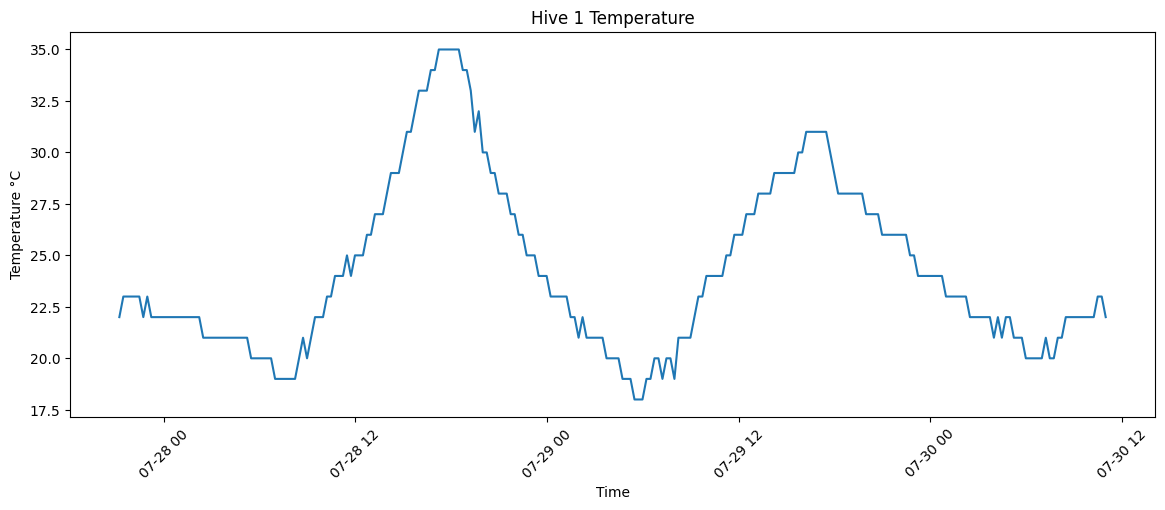

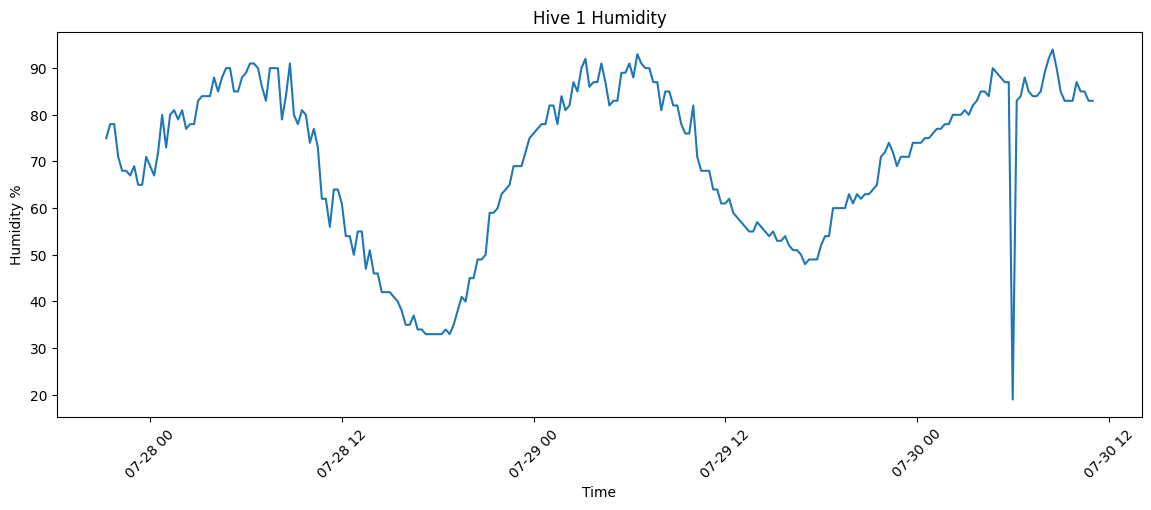

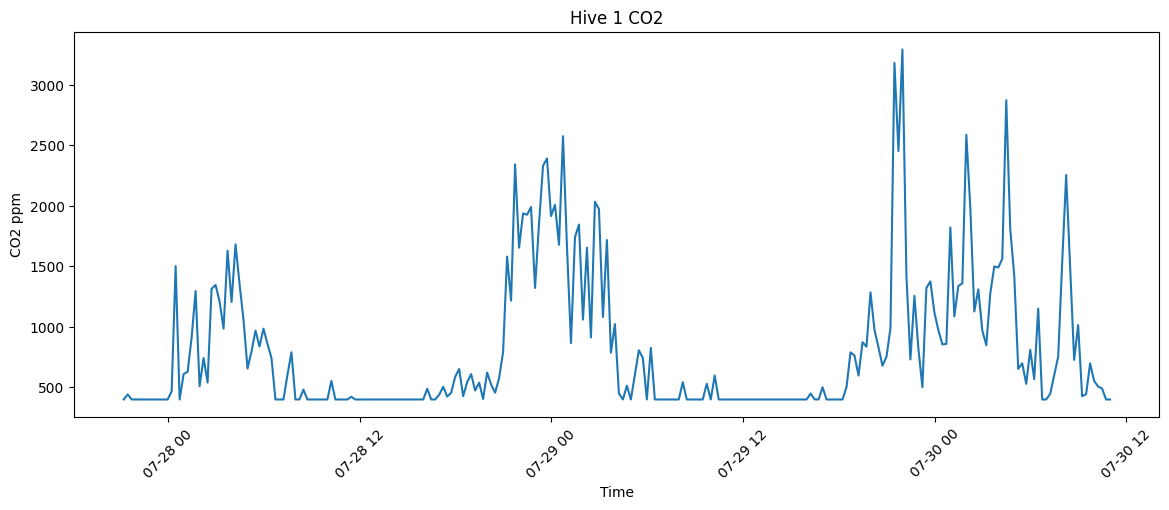

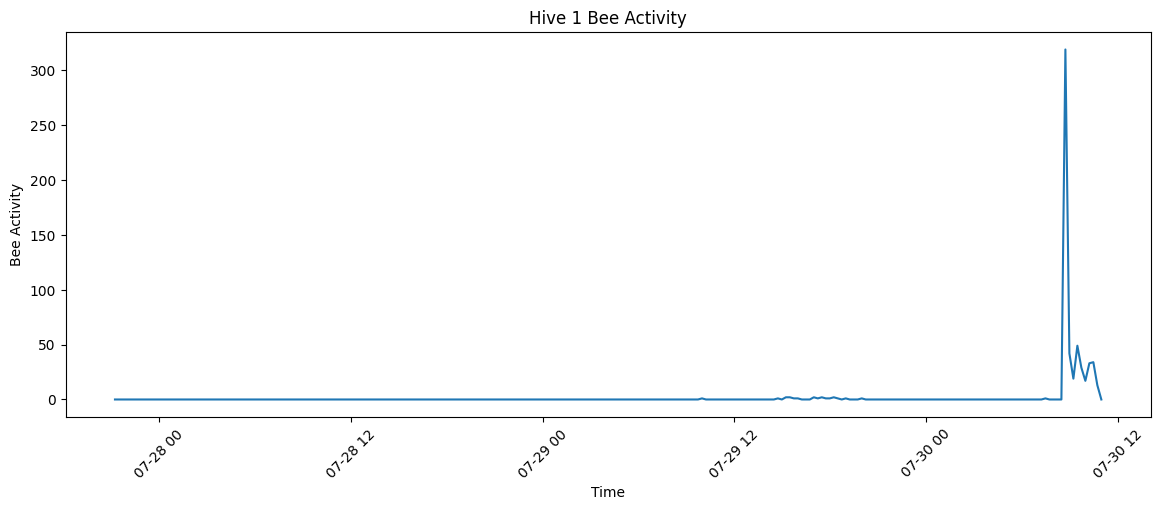

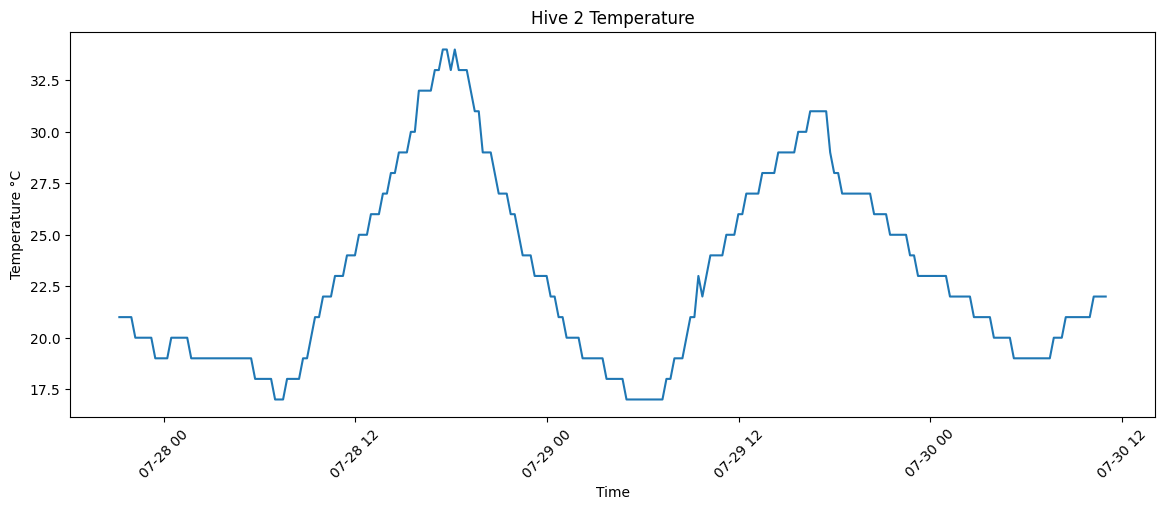

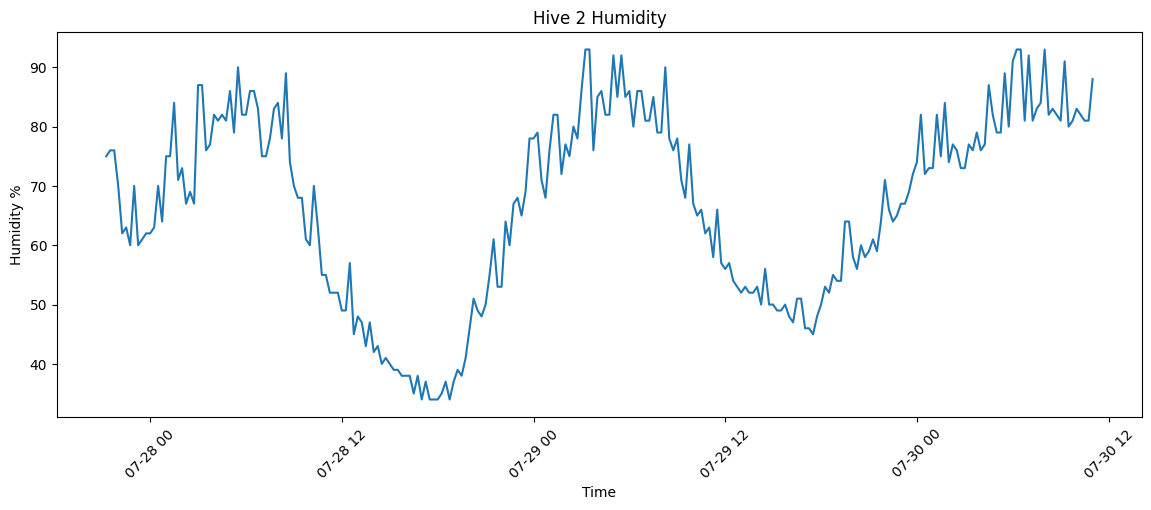

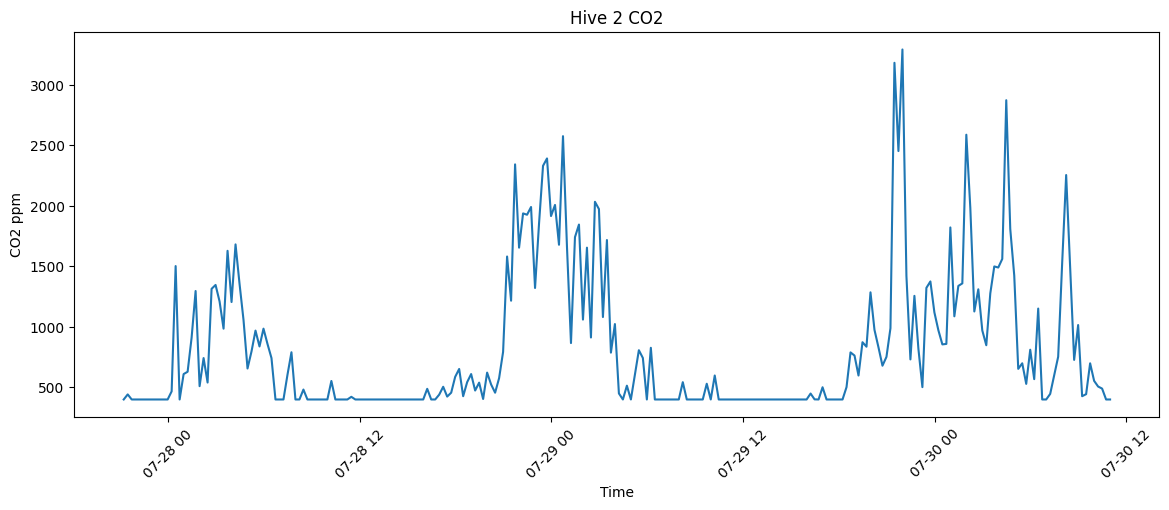

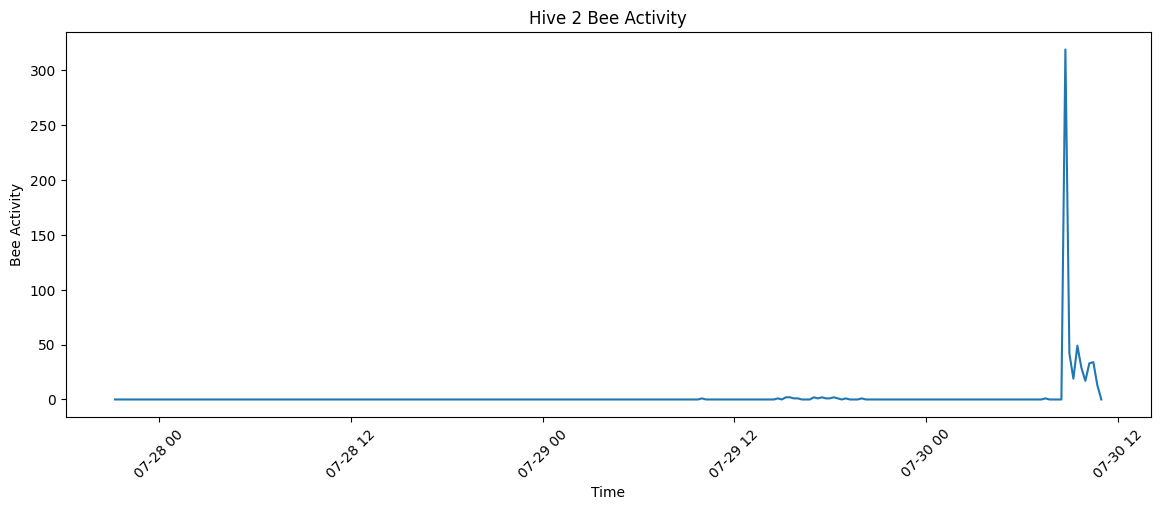

In [ ]:
import matplotlib.pyplot as plt


def plot_hive_history(
    dataframe,
    hive_id
):

    plt.figure(
        figsize=(14, 5)
    )

    plt.plot(
        dataframe["Timestamp"],
        dataframe["HiveTemp"]
    )

    plt.xlabel("Time")
    plt.ylabel("Temperature °C")

    plt.title(
        f"Hive {hive_id} Temperature"
    )

    plt.xticks(rotation=45)

    plt.show()



    plt.figure(
        figsize=(14, 5)
    )

    plt.plot(
        dataframe["Timestamp"],
        dataframe["HiveHumidity"]
    )

    plt.xlabel("Time")
    plt.ylabel("Humidity %")

    plt.title(
        f"Hive {hive_id} Humidity"
    )

    plt.xticks(rotation=45)

    plt.show()



    plt.figure(
        figsize=(14, 5)
    )

    plt.plot(
        dataframe["Timestamp"],
        dataframe["CO2_eq (ppm)"]
    )

    plt.xlabel("Time")
    plt.ylabel("CO2 ppm")

    plt.title(
        f"Hive {hive_id} CO2"
    )

    plt.xticks(rotation=45)

    plt.show()



    plt.figure(
        figsize=(14, 5)
    )

    plt.plot(
        dataframe["Timestamp"],
        dataframe["BeeActivity"]
    )

    plt.xlabel("Time")
    plt.ylabel("Bee Activity")

    plt.title(
        f"Hive {hive_id} Bee Activity"
    )

    plt.xticks(rotation=45)

    plt.show()



plot_hive_history(
    results[1]["data"],
    1
)

plot_hive_history(
    results[2]["data"],
    2
)

### *CODE FOR REAL TIME IOT DATA(FUTURE USE)*

In [ ]:
# ============================================================
# REAL-TIME / FUTURE INFERENCE PIPELINE
# ============================================================

def load_saved_model(hive_id):

    model_path = os.path.join(

        MODEL_FOLDER,

        f"hive_{hive_id}_isolation_forest.joblib"

    )


    if not os.path.exists(model_path):

        raise FileNotFoundError(
            f"Model not found: {model_path}"
        )


    model = joblib.load(
        model_path
    )


    return model



def analyse_live_dataset(file_path):

    print(
        "\nReading live sensor dataset..."
    )


    raw = load_sensor_data(
        file_path
    )


    validate_dataset(raw)


    raw = clean_data(raw)


    reports = {}


    for hive_id in [1, 2]:

        print(
            f"\nAnalysing Hive {hive_id}"
        )


        data = create_features(
            raw,
            hive_id
        )


        model = load_saved_model(
            hive_id
        )


        data = apply_model(
            data,
            model
        )


        data = add_health_scores(
            data
        )


        report = generate_health_report(
            data,
            hive_id
        )


        print_report(
            report
        )


        save_report(
            report,
            hive_id
        )


        reports[hive_id] = report


    return reports

In [ ]:
live_reports = analyse_live_dataset(
    DATA_FILE
)


Reading live sensor dataset...
Loading: /content/drive/MyDrive/HONEY_HEALTH_MONITOR/SensorLog.csv
Rows: 248
Columns: 13
Dataset validation successful.

Analysing Hive 1


🐝 HIVE HEALTH REPORT - HIVE_01
Temperature       : 22.08 °C
Humidity          : 86.08 %
Pressure          : 985.14 hPa
CO2               : 783.42 ppm
TVOC              : 230.58 ppb
Bee Activity      : 46.25
------------------------------------------------------------
HEALTH SCORE      : 93.0 / 100
HEALTH STATUS     : Warning
ANOMALIES         : 4
ANOMALY RATE      : 33.33 %
------------------------------------------------------------
🚨 INSPECTION REQUIRED: YES

Reasons:
 • 4 unusual sensor patterns detected in recent readings
 • Recent average hive humidity is high
Report saved: /content/drive/MyDrive/HONEY_HEALTH_MONITOR/reports/hive_1_latest_report.json

Analysing Hive 2


🐝 HIVE HEALTH REPORT - HIVE_02
Temperature       : 21.25 °C
Humidity          : 82.92 %
Pressure          : 985.14 hPa
CO2               : 783.4

### **Automatically check the Google Drive dataset for new IoT readings**

In [ ]:
import time
import os


def monitor_sensor_file(
    file_path,
    check_every_seconds=60
):

    print(
        "🐝 Hive monitoring started..."
    )

    print(
        "Watching:",
        file_path
    )


    previous_modified_time = None


    while True:

        try:

            current_modified_time = (
                os.path.getmtime(
                    file_path
                )
            )


            if (
                previous_modified_time is None
                or
                current_modified_time
                !=
                previous_modified_time
            ):

                print(
                    "\nNew sensor data detected!"
                )


                analyse_live_dataset(
                    file_path
                )


                previous_modified_time = (
                    current_modified_time
                )


            else:

                print(
                    "No new data..."
                )


            time.sleep(
                check_every_seconds
            )


        except KeyboardInterrupt:

            print(
                "\nMonitoring stopped."
            )

            break


        except Exception as e:

            print(
                "Monitoring error:",
                e
            )


            time.sleep(
                check_every_seconds
            )

In [ ]:
monitor_sensor_file(
    DATA_FILE,
    check_every_seconds=60
)

🐝 Hive monitoring started...
Watching: /content/drive/MyDrive/HONEY_HEALTH_MONITOR/SensorLog.csv

New sensor data detected!

Reading live sensor dataset...
Loading: /content/drive/MyDrive/HONEY_HEALTH_MONITOR/SensorLog.csv
Rows: 248
Columns: 13
Dataset validation successful.

Analysing Hive 1


🐝 HIVE HEALTH REPORT - HIVE_01
Temperature       : 22.08 °C
Humidity          : 86.08 %
Pressure          : 985.14 hPa
CO2               : 783.42 ppm
TVOC              : 230.58 ppb
Bee Activity      : 46.25
------------------------------------------------------------
HEALTH SCORE      : 93.0 / 100
HEALTH STATUS     : Warning
ANOMALIES         : 4
ANOMALY RATE      : 33.33 %
------------------------------------------------------------
🚨 INSPECTION REQUIRED: YES

Reasons:
 • 4 unusual sensor patterns detected in recent readings
 • Recent average hive humidity is high
Report saved: /content/drive/MyDrive/HONEY_HEALTH_MONITOR/reports/hive_1_latest_report.json

Analysing Hive 2


🐝 HIVE HEALTH REPORT

In [ ]:
import joblib
import os

joblib.dump(
    results[1]["model"],
    os.path.join(MODEL_FOLDER, "hive_1_isolation_forest.joblib")
)

joblib.dump(
    results[2]["model"],
    os.path.join(MODEL_FOLDER, "hive_2_isolation_forest.joblib")
)

['/content/drive/MyDrive/HONEY_HEALTH_MONITOR/models/hive_2_isolation_forest.joblib']

In [ ]:
import json
from datetime import datetime
import os

metadata = {
    "model_version": "1.0.0",
    "algorithm": "IsolationForest",
    "trained_at": datetime.now().isoformat(),
    "contamination": 0.05,
    "hives": ["HIVE_01", "HIVE_02"]
}

with open(
    os.path.join(MODEL_FOLDER, "metadata.json"),
    "w"
) as f:
    json.dump(metadata, f, indent=4)

In [ ]:
feature_config = {
    "features": [
        "HiveTemp",
        "HiveHumidity",
        "TempOut (°C)",
        "HumOut (%)",
        "Pressure (hPa)",
        "CO2_eq (ppm)",
        "TVOC (ppb)",
        "Light (-)",
        "BeeActivity",
        "BeeFlowDifference",
        "TempDelta",
        "HumidityDelta",
        "PressureDelta",
        "CO2Delta",
        "BeeActivityDelta",
        "TempRollingMean",
        "TempRollingStd",
        "HumidityRollingMean",
        "HumidityRollingStd",
        "CO2RollingMean",
        "BeeActivityRollingMean",
        "TempInsideOutsideDiff",
        "HumidityInsideOutsideDiff",
        "Hour",
        "DayOfWeek",
        "IsDay"
    ]
}

with open(
    "/content/drive/MyDrive//HONEY_HEALTH_MONITOR/models/feature_config.json",
    "w"
) as f:
    json.dump(feature_config, f, indent=4)